# GARCH MODEL
In the financial industry, GARCH models are a popular approach to model volatility.

Firstly, we need to calculate daily returns as the percentage price changes, plot the results and observe its behavior over time.
We will use the market_data class

In [2]:
import importlib
import market_data

importlib.reload(market_data)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
# Asset to analyze
ric = "BBVA"

# Create analysis object
asset = market_data.distribution_manager(ric)

# Load time series and compute returns
asset.load_timeseries() # from_date='2025-12-02'


In [4]:
# Convert date column to datetime
asset.timeseries['date'] = pd.to_datetime(asset.timeseries['date'])

# Set date as index
asset.timeseries= asset.timeseries.set_index('date')

# Keep only returns
returns = asset.timeseries[['return']]

print(returns.head())

              return
date                
2018-01-03  0.001694
2018-01-04  0.017902
2018-01-05  0.004432
2018-01-08 -0.002482
2018-01-09  0.003732


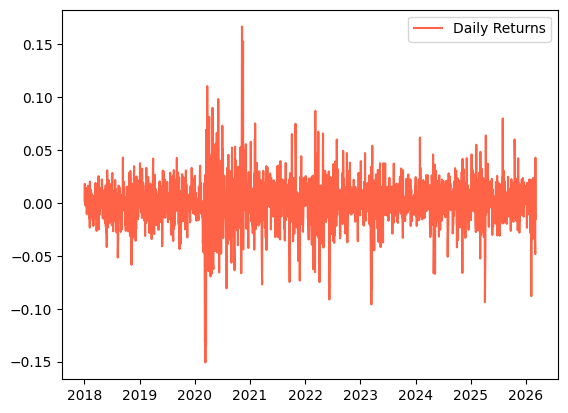

In [5]:
# Plot the data
plt.plot(returns, color = 'tomato', label = 'Daily Returns')
plt.legend(loc='upper right')
plt.show()

In [6]:
# Calculate daily std of returns
std_daily = returns['return'].std()
print('Daily volatility: ', '{:.2f}%'.format(std_daily))

# Convert daily volatility to monthly volatility
std_monthly = np.sqrt(21) * std_daily
print ('Monthly volatility: ', '{:.2f}%'.format(std_monthly))

# Convert daily volatility to annaul volatility
std_annual = np.sqrt(252) * std_daily
print ('Annual volatility: ', '{:.2f}%'.format(std_annual))

Daily volatility:  0.02%
Monthly volatility:  0.10%
Annual volatility:  0.34%


# Interpreting Daily Volatility (Standard Deviation of Returns)

## 1. What the Result Means

Daily volatility is the **standard deviation of daily returns**, which measures how much the price typically moves away from its average return in a single trading day.

Example:

Daily volatility: **0.94%**

Interpretation:

- On a typical day, the asset's return moves about **±0.94% around its mean return**.
- Rough statistical intuition:
  - ~68% of the time → returns fall within **±0.94%**
  - ~95% of the time → returns fall within **±1.88%**
  - ~99% of the time → returns fall within **±2.82%**

This does **not mean the asset moves exactly that amount**, but that this is the **typical dispersion of daily returns**.

---

# Interpreting Daily Volatility (Quick Reference)

## 1. Is 0.94% High?

For a broad equity index like the **S&P 500**, a daily volatility of **0.94%** is **normal**.

Typical ranges for equity markets:

| Market Condition | Daily Volatility |
|------------------|------------------|
| Very calm markets | 0.3% – 0.6% |
| Normal equities | 0.7% – 1.2% |
| Volatile equities | 1.5% – 2.5% |
| Crisis periods | 3% – 6% |

**Conclusion:**  
`0.94% → Normal equity market volatility`

---

# 2. What About 0.02% Daily Volatility?

A daily volatility of **0.02%** is **extremely low**.

This usually corresponds to very stable assets such as:

- Short-term bonds  
- Money market instruments  
- Currency pegs  
- Ultra-stable bond ETFs  

Typical ranges:

| Asset Type | Daily Volatility |
|-----------|------------------|
| Short-term bonds | 0.01% – 0.10% |
| Money markets | 0.005% – 0.03% |

**Conclusion:**  
`0.02% → Extremely stable asset`

---

# 3. Typical Daily Volatility by Asset Class

### Equity Indexes (S&P 500, MSCI World)

| Condition | Daily Vol |
|----------|-----------|
| Calm markets | ~0.6% |
| Normal | 0.8% – 1.2% |
| Crisis | 2% – 5% |

Typical **annual volatility:**  
`12% – 20%`

---

### Individual Stocks

| Type | Daily Vol |
|------|-----------|
| Large cap | 1% – 2% |
| Mid cap | 1.5% – 3% |
| Small cap | 2% – 5% |

Typical **annual volatility:**  
`20% – 50%`

---

### Commodities

| Commodity | Daily Vol |
|-----------|-----------|
| Gold | 0.8% – 1.3% |
| Oil | 1.5% – 3% |
| Natural Gas | 3% – 6% |

---

### Forex

| Market | Daily Vol |
|------|-----------|
| Major pairs (EURUSD) | 0.4% – 0.8% |
| Minor pairs | 0.7% – 1.2% |
| Emerging FX | 1% – 2% |

---

### Crypto

Crypto markets are **much more volatile**.

| Asset | Daily Vol |
|------|-----------|
| Bitcoin | 3% – 5% |
| Ethereum | 4% – 6% |
| Altcoins | 6% – 15% |

Typical **annual volatility:**  
`60% – 120%`

---

# 4. Quick Rule of Thumb

| Daily Volatility | Interpretation |
|------------------|---------------|
| < 0.05% | Ultra stable |
| ~0.1% | Bonds / very low risk |
| ~0.5% | Calm equity markets |
| ~1% | Normal stock market |
| ~2% | High volatility |
| 3%+ | Stress / speculation |
| 5%+ | Extremely volatile (crypto or crises) |

---

# 5. Practical Intuition

If you see:

`Daily volatility = 0.94%`

Think:

> "The market typically moves about **1% per day**, which is normal for large equity indices."

If you see:

`Daily volatility = 0.02%`

Think:

> "The asset barely moves day-to-day; it behaves like **cash or short-term bonds**."

# GARCH Model Assumptions

A **GARCH (Generalized Autoregressive Conditional Heteroskedasticity)** model is used to model **time-varying volatility** in financial returns. It **assumes that volatility changes over time and depends on past shocks and past volatility**.

---

# Main Assumptions of a GARCH Model

1. **Returns are (weakly) stationary**
   - The return series should have a constant mean and finite variance over time.
   - Prices are typically **non-stationary**, which is why GARCH models are applied to **returns instead of prices**.

2. **Conditional heteroskedasticity**
   - The variance of the residuals is **not constant**.
   - Instead, it changes over time and depends on past information.

3. **Volatility clustering**
   - Large shocks tend to be followed by large shocks.
   - Small shocks tend to be followed by small shocks.
   - This is a key empirical property of financial markets.

4. **Residuals have zero mean**
   - After modeling the mean process (often constant mean or ARMA), the residuals satisfy:

   E(εₜ) = 0

5. **Conditional variance must be positive**
   - The variance equation must ensure:

   σₜ² > 0

6. **Parameter restrictions (stability condition)**

For a **GARCH(1,1)** model:

σₜ² = ω + αε²ₜ₋₁ + βσ²ₜ₋₁

The parameters must satisfy:

ω > 0  
α ≥ 0  
β ≥ 0  
α + β < 1  

This ensures the process is **covariance stationary** and volatility does not explode over time.

7. **Distributional assumption for errors**
   - Often assumed:

   εₜ ~ N(0, σₜ²)

   However, financial returns frequently exhibit **fat tails**, so in practice a **Student-t distribution** is often used.

---

## Are GARCH Assumptions the Same as ARCH?

Yes, **they are essentially the same**, because **GARCH is an extension of ARCH**.

### ARCH(q)

Variance depends only on **past squared shocks**:

σₜ² = ω + α₁ε²ₜ₋₁ + ... + αqε²ₜ₋q

### GARCH(p,q)

Variance depends on both:

- past **squared shocks**
- past **conditional variances**

Example GARCH(1,1):

σₜ² = ω + αε²ₜ₋₁ + βσ²ₜ₋₁

The additional term **βσ²ₜ₋₁** introduces **volatility persistence**.

---

## Parameters interpretation:

| Parameter | Meaning |
|-----------|--------|
| ω | Long-run variance level |
| α | Reaction to new shocks (ARCH effect) |
| β | Persistence of volatility (GARCH effect) |

Typical empirical values in financial markets:

α ≈ 0.05 – 0.15  
β ≈ 0.80 – 0.95  

This means volatility is **highly persistent**.

---

## When β = 0

If:

β = 0

The model becomes:

σₜ² = ω + αε²ₜ₋₁

Which is exactly an **ARCH(1)** model.

So mathematically:

**ARCH is a special case of GARCH where β = 0.**

---

## Key Intuition

In financial markets it is common to observe:

α + β ≈ 0.9 to 0.99

This implies **strong volatility persistence**, meaning that once volatility increases, it tends to **remain elevated for some time before slowly decaying**.

# Simulating ARCH and GARCH series
Over the same model GARCH(1,1), we played with beta (0 by default i.e. ARCH model)... we took the resid and variance values to plot them.

# Implementing a basic GARCH model - Code
We will get familiar with the Python arch package, and use its functions such as arch_model() to implement a GARCH(1,1) model.

First define a basic GARCH(1,1) model, then fit the model, review the model fitting summary, and plot the results.

Optimization terminated successfully    (Exit mode 0)
            Current function value: -5259.867930881595
            Iterations: 2
            Function evaluations: 27
            Gradient evaluations: 2
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                5259.87
Distribution:                  Normal   AIC:                          -10511.7
Method:            Maximum Likelihood   BIC:                          -10489.2
                                        No. Observations:                 2090
Date:                Wed, Mar 11 2026   Df Residuals:                     2089
Time:                        09:53:08   Df Model:                            1
                                 Mean Model                                 
    

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004715. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


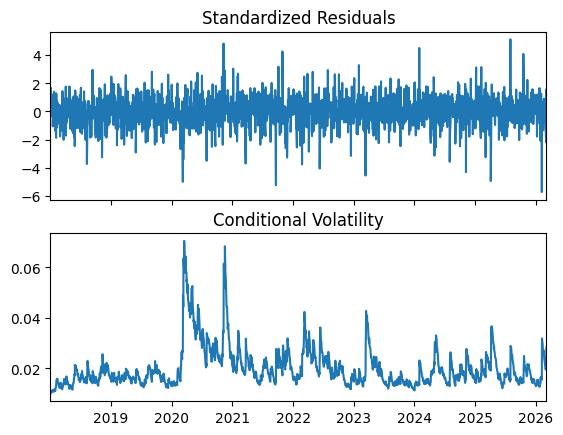

In [7]:
from arch import arch_model

# Specify GARCH model assumptions
basic_gm = arch_model(returns, p = 1, q = 1,
                      mean = 'constant', vol = 'GARCH', dist = 'normal')
# Fit the model
gm_result = basic_gm.fit(update_freq = 4)

# Display model fitting summary
print(gm_result.summary())

# Plot fitted results
gm_result.plot()
plt.show()

# Intuition Behind GARCH Diagnostics - Notes

## 1. Raw Returns (Before the Model)

When we plot raw financial returns:

rₜ

we typically observe **heteroskedasticity**.

This means:

Var(rₜ) changes over time.

In the plot this appears as **volatility clustering**:

small moves small moves small moves
BIG moves BIG moves BIG moves
small moves small moves

So raw returns usually show:

• changing variance  
• clusters of large shocks  
• clusters of small shocks  

This behavior is a well-known property of financial markets.

---

## 2. What the GARCH Model Does

A GARCH model estimates **time-varying volatility**:

σₜ² = ω + αε²ₜ₋₁ + βσ²ₜ₋₁

Instead of assuming constant variance, the model estimates:

σₜ

which is the **conditional volatility at each time t**.

---

## 3. Standardized Residuals

After estimating volatility, we standardize the shocks:

zₜ = εₜ / σₜ

This removes the effect of changing volatility.

If the model is correctly specified:

zₜ should behave like **white noise**.

That means:

• mean ≈ 0  
• variance ≈ 1  
• no volatility clustering  

In other words:

Raw returns → heteroskedastic  
Standardized residuals → approximately homoskedastic

Yes — **this should be visible in the plot**.

The standardized residuals should look like random noise with **no clusters of large movements**.

---

## 4. Conditional Volatility Plot - Standard Deviation of... residuals

The conditional volatility plot shows:

σₜ

This represents the **estimated market volatility through time**.

It tells us when the market experienced:

• stress
• shocks
• turbulence

Typical interpretation:

volatility spike → crisis / large market shock  
low volatility → calm market period

For example:

financial crisis  
commodity shocks  
macro uncertainty  

will appear as **large spikes in conditional volatility**.

---

## 5. Big Picture

The full workflow is:

1. Plot returns  
   → observe volatility clustering (heteroskedasticity)

2. Fit GARCH model  
   → estimate time-varying volatility

3. Plot standardized residuals  
   → check if clustering disappeared

4. Plot conditional volatility  
   → identify stress periods in the market

If the model works well:

returns = heteroskedastic  
standardized residuals = homoskedastic

## Interpreting GARCH Model Plots

After fitting a GARCH model we usually inspect two important diagnostics:

1. Standardized residuals
2. Conditional volatility

These plots help verify whether the model successfully captured the time-varying volatility of the returns.

---

### 1. Standardized Residuals

Standardized residuals are defined as:

zₜ = εₜ / σₜ

Where:

εₜ = model residual (market shock)  
σₜ = conditional volatility estimated by the GARCH model  

This transformation removes the effect of changing volatility.

Important:

This is **NOT the same as plotting raw returns**.

Raw returns:

rₜ

Standardized residuals:

zₜ = εₜ / σₜ

The goal is that standardized residuals behave like **white noise**.

If the model is well specified:

zₜ ~ N(0,1)

So the plot should show:

- no volatility clustering
- mean around zero
- roughly constant variance

If clustering still appears, the model did not fully capture volatility dynamics.

---

### 2. Conditional Volatility

The second plot shows:

σₜ

which is the **time-varying volatility estimated by the GARCH model**.

Financial markets typically exhibit **volatility clustering**:

- calm periods → low volatility
- crisis periods → large volatility spikes

The GARCH model captures this by allowing volatility to evolve over time.

Typical pattern:

shock → volatility increases  
volatility → slowly decays  

This persistence is one of the main stylized facts of financial markets.

---

## Why Standardization is Important

Returns themselves have **heteroskedasticity**:

Var(rₜ) changes over time.

After fitting GARCH and standardizing residuals we expect:

Var(zₜ) = 1

This means the model successfully removed the volatility dynamics.

In other words:

returns → heteroskedastic  
standardized residuals → approximately homoskedastic

# Making forecasting - Notes

## GARCH Forecast: What Does `forecast(horizon=5)` Do?

When we run:

gm_forecast = gm_result.forecast(horizon = 5)

we are asking the GARCH model to compute **future forecasts of conditional variance**.

Important:

The model **does NOT forecast prices**.

It forecasts:

future **volatility (variance)**.

---

## Does `horizon = 5` Mean the Next 5 Days?

Yes.

If your data are **daily returns**, then:

horizon = 5

means the model estimates:

σ²(t+1)  
σ²(t+2)  
σ²(t+3)  
σ²(t+4)  
σ²(t+5)

These are the **predicted variances of returns for the next 5 periods**.

If the data are daily → next **5 trading days**.

---

## What Is Inside `gm_forecast`?

`gm_forecast` is an object that contains several useful components.

The most important ones are:

### 1. Mean forecast

gm_forecast.mean

Forecast of the **expected return**.

In many financial models this is close to zero because returns have very small predictable components.

---

### 2. Variance forecast

gm_forecast.variance

This is the **most important output**.

It contains the predicted:

Var(r_t)

for each forecast horizon.

Example output:

h.1   h.2   h.3   h.4   h.5
0.85  0.88  0.91  0.92  0.93

These are **future volatility estimates (squared)**.

To obtain volatility:

σ = sqrt(variance)

---

### 3. Residual variance forecast

gm_forecast.residual_variance

This is similar to variance but refers to:

Var(ε_t)

which is the **innovation variance**.

In many simple models it is the same as the conditional variance.

---

## Why Do We Use This Forecast?

Volatility forecasts are extremely important in finance.

They are used for:

Risk management
Value-at-Risk (VaR)
Portfolio allocation
Options pricing
Trading position sizing
Stress detection

Example interpretation:

If predicted volatility for tomorrow increases strongly,
the market is expected to be **more unstable**.

---

## Example: Accessing the Forecasts

Variance forecast:

gm_forecast.variance

Last forecast:

gm_forecast.variance[-1:]

Convert to volatility:

np.sqrt(gm_forecast.variance[-1:])

---

## Example Interpretation

Suppose the model outputs:

h.1 = 1.2
h.2 = 1.1
h.3 = 1.0
h.4 = 0.95
h.5 = 0.90

This means:

The market is currently in a **high volatility regime**, but the model expects volatility to **slowly decay over the next days**.

This behavior is typical of GARCH because volatility is **persistent but mean-reverting**.

# Making forecasting - Code

In [8]:
# Make 5-period ahead forecast
gm_forecast = gm_result.forecast(horizon = 5)

# Print the forecast variance
print(gm_forecast.variance[-1:])

                 h.1       h.2       h.3       h.4       h.5
date                                                        
2026-03-05  0.000737  0.000731  0.000726  0.000721  0.000716


# Plot distribution of standardized residuals
Remember that these must follow a Standard Normal distribution with parameters 0 and 1
GARCH models make distribution assumptions of the standardized residuals. Recall residuals are the differences between predicted returns and the mean returns. And standardized residuals are the residuals divided by the model estimated volatility.

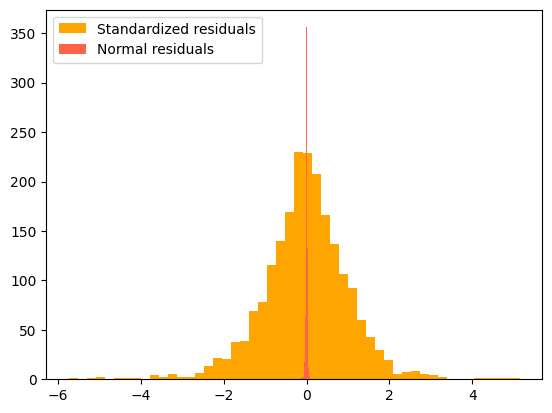

In [9]:
# We already created the model
# We fitted it... gm_result = model.fit(update_freq = n)
# And now we will be working with the attributes of the previous variable obtained...

# Obtain model estimated residuals and volatility
gm_resid = gm_result.resid
gm_std = gm_result.conditional_volatility

# Calculate the standardized residuals
gm_std_resid = gm_resid /gm_std

# Plot the histogram of the standardized residuals
plt.hist(gm_std_resid, bins = 50, 
         facecolor = 'orange', label = 'Standardized residuals')
plt.hist(gm_resid, bins = 50, 
         facecolor = 'tomato', label = 'Normal residuals')
plt.legend(loc = 'upper left')
plt.show()

# Fit a GARCH with skewed t-distribution
The default normal distribution assumption of the standardized residuals used in GARCH models are not representative of the real financial world. 
Fat tails and skewness are frequently observed in financial return data.
We will compare the model estimated volatility with that from a model with a normal distribution assumption by plotting them together.

Iteration:      1,   Func. Count:      8,   Neg. LLF: 53622.236052783446
Iteration:      2,   Func. Count:     25,   Neg. LLF: 279876.4560137233
Iteration:      3,   Func. Count:     42,   Neg. LLF: 3501.9117423001617
Iteration:      4,   Func. Count:     48,   Neg. LLF: 3813.790272362555
Inequality constraints incompatible    (Exit mode 4)
            Current function value: 3501.9117423001617
            Iterations: 4
            Function evaluations: 48
            Gradient evaluations: 4


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004715. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/var/folders/kz/rybrs64563zc2gl94rf00qbw0000gn/T/ipykernel_52689/3535639918.py:5: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  skewt_result = skewt_gm.fit()


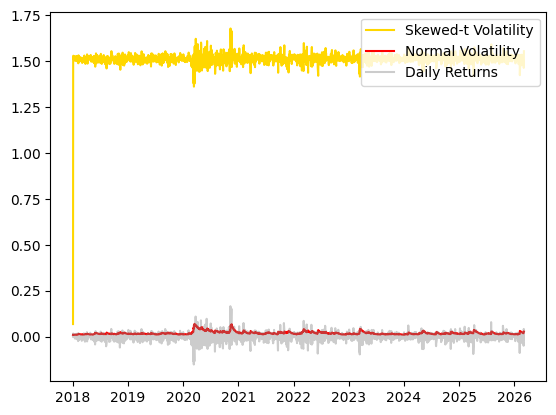

In [10]:
# Specify GARCH model assumptions
skewt_gm = arch_model(returns, p = 1, q = 1, mean = 'constant', vol = 'GARCH', dist = 'skewt')

# Fit the model
skewt_result = skewt_gm.fit()

# Get model estimated volatility
skewt_vol = skewt_result.conditional_volatility # OBTAINING THE RESIDUAL´S STANDARD DEVIATION 

# Plot model fitting results
plt.plot(skewt_vol, color = 'gold', label = 'Skewed-t Volatility')
plt.plot(gm_std, color = 'red', label = 'Normal Volatility')
plt.plot(returns, color = 'grey', 
         label = 'Daily Returns', alpha = 0.4)
plt.legend(loc = 'upper right')
plt.show()

# Effect of mean model on volatility predictions

In practice, returns and volatility are modeled in separate processes. Typically the mean assumptions influence predicted returns, but have a minor effect on the volatility estimations.

We will examine the impact of GARCH model mean assumptions on volatility estimations by comparing two GARCH models.

## Difference Between Constant Mean and AR Mean in a GARCH Model

A GARCH model has **two equations**:

1) Mean equation (models expected return)
2) Variance equation (models volatility)

General structure:

Mean equation:
r_t = μ + ε_t

Variance equation:
σ_t^2 = ω + αε_{t-1}^2 + βσ_{t-1}^2

---

### 1. Constant Mean Model

In a **constant mean model**, returns are assumed to fluctuate around a fixed average.

Mean equation:

r_t = μ + ε_t

Where:

μ = constant expected return  
ε_t = shock

This assumes **returns are unpredictable**, which is often a reasonable assumption for financial markets.

Most equity return models use constant mean because:

expected returns are very small  
short-term predictability is weak

---

### 2. AR Mean Model

In an **AR (Autoregressive) mean model**, the current return depends on past returns.

Example AR(1):

r_t = μ + φ r_{t-1} + ε_t

Where:

φ measures autocorrelation in returns.

Interpretation:

If φ > 0 → returns show momentum  
If φ < 0 → returns show mean reversion

The AR term captures **serial correlation in returns**.

---

## Why Try Different Mean Models?

Because before modeling volatility we must remove **predictable structure in returns**.

Workflow:

1) model the mean process
2) obtain residuals
3) model volatility of residuals

If the mean is misspecified, the volatility model may absorb patterns that belong to the mean.

---

## Why Are the Volatility Estimates Almost Identical?

In financial returns:

autocorrelation in returns is usually **very close to zero**.

So:

Constant Mean:

r_t = μ + ε_t

AR Mean:

r_t = μ + φ r_{t-1} + ε_t

If φ ≈ 0, both models produce **almost identical residuals**.

Since GARCH models volatility of residuals:

σ_t^2 = f(ε_t)

the volatility estimates end up being nearly the same.

That is why you often see:

corr(vol_const_mean, vol_AR_mean) ≈ 1

---

## Practical Interpretation

In most financial datasets:

Mean dynamics are weak  
Volatility dynamics are strong

So:

Mean model → small impact  
Volatility model → large impact

This is why many volatility studies simply use:

Constant Mean + GARCH(1,1)

---

## Rule of Thumb in Quant Finance

Mean equation → usually simple  
Variance equation → where most of the modeling power is

Returns are hard to predict, but **volatility is predictable**.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004715. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004715. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._

Optimization terminated successfully    (Exit mode 0)
            Current function value: -5259.867930881595
            Iterations: 2
            Function evaluations: 27
            Gradient evaluations: 2
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                5259.87
Distribution:                  Normal   AIC:                          -10511.7
Method:            Maximum Likelihood   BIC:                          -10489.2
                                        No. Observations:                 2090
Date:                Wed, Mar 11 2026   Df Residuals:                     2089
Time:                        09:53:09   Df Model:                            1
                                 Mean Model                                 
    

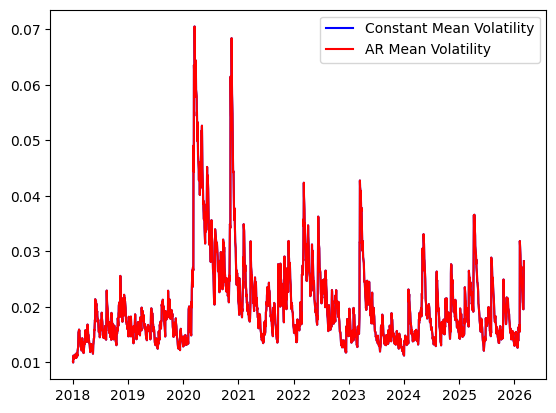

0.9999999999999998


In [11]:
# GARCH model with constant mean
cmean = arch_model(returns, p = 1, q = 1, mean = 'constant', vol = 'GARCH', dist = 'normal')
cmean_result = cmean.fit(update_freq = 4)
# Print model summary of GARCH with constant mean
print(cmean_result.summary())

# GARCH model with AR mean
armean = arch_model(returns, p = 1, q = 1, mean = 'AR', vol = 'GARCH', dist = 'normal')
armean_result = armean.fit(update_freq = 4)
# Print model summary of GARCH with AR mean
print(armean_result.summary())

# Plot model volatility
cmean_vol = cmean_result.conditional_volatility # La volatilidad estimada por el modelo.
armean_vol = armean_result.conditional_volatility # La volatilidad estimada por el modelo.
plt.plot(cmean_vol, color = 'blue', label = 'Constant Mean Volatility')
plt.plot(armean_vol, color = 'red', label = 'AR Mean Volatility')
plt.legend(loc = 'upper right')
plt.show()

# Check correlation of volatility estimations
print(np.corrcoef(cmean_vol, armean_vol)[0,1])

# Fixed rolling window forecast

Rolling-window forecasts are very popular for financial time series modeling.
## How to Define start_loc and end_loc for Rolling GARCH Forecasts

When using:

gm_result = basic_gm.fit(first_obs = ..., last_obs = ...)

the arguments **first_obs** and **last_obs** refer to:

index positions in the dataset.

They are NOT random numbers and they are NOT dates.

---

### Step 1: Check the length of your dataset

First verify how many observations you have.

Example:

len(returns)

Example output:

2108

This means your positions go from:

0 → 2107

---

### Step 2: Choose the training window

In the example:

start_loc = 1800
end_loc = 1920

The model will fit using:

observations 1800 → 1920

That means the training window size is:

window_size = end_loc - start_loc

Example:

1920 - 1800 = 120 observations

So the model is trained using the last **120 returns**.

---

### Step 3: Why the window moves in the loop

Inside the loop:

first_obs = i + start_loc
last_obs  = i + end_loc

The estimation window moves forward.

Example:

iteration 0

1800 → 1920

iteration 1

1801 → 1921

iteration 2

1802 → 1922

This is called a **rolling window**.

---

### Step 4: Why errors happen

Errors usually occur when:

1. The dataset is shorter than expected.

Example:

len(data) = 1900

but you set:

end_loc = 1920

This exceeds the available observations.

---

### Step 5: Safe way to define them

A common approach is:

n = len(returns)

start_loc = n - 300
end_loc   = n - 180

This guarantees the indices exist.

---

### Step 6: Example

If:

len(data) = 2108

then:

start_loc = 1800
end_loc   = 1920

means:

use observations 1800–1920 to estimate the model.

Then the rolling loop generates volatility forecasts for the following periods.

---

## Key Idea

These values define the **training window of the model**, not the forecast horizon.

The forecast horizon is controlled by:

forecast(horizon = 1)

In [12]:
from arch import arch_model

basic_gm = arch_model(
    returns,
    mean='Constant',
    vol='GARCH',
    p=1,
    q=1
)

print(len(returns))
# Both must be into the data range...
start_loc = 1800
end_loc = 1920


2090


In [13]:
'''forecasts = {}
for i in range(30):
    # Specify fixed rolling window size for model fitting
    gm_result = basic_gm.fit(first_obs = i + start_loc, 
                             last_obs = i + end_loc, update_freq = 5)
    # Conduct 1-period variance forecast 
    temp_result = gm_result.forecast(horizon = 1).variance
    fcast = temp_result.iloc[-1] # The last row of the forecast
    forecasts[fcast.name] = fcast
# Save all forecast to a DataFrame   
forecast_var = pd.DataFrame(forecasts).T # Transpose
forecast_var.head()'''

forecasts = {}

for i in range(30):

    gm_result = basic_gm.fit(
        first_obs = i + start_loc,
        last_obs = i + end_loc,
        update_freq = 5,
        disp="off"
    )

    temp_result = gm_result.forecast(horizon=1).variance

    # tomar el forecast correcto
    fcast = temp_result.iloc[0]

    forecasts[fcast.name] = fcast

forecast_var = pd.DataFrame(forecasts).T

forecast_var

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004231. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004239. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._

,h.1
2025-07-07,0.000400
2025-07-08,0.000390
2025-07-09,0.000385
2025-07-10,0.000400
2025-07-11,0.000468
2025-07-14,0.000427
2025-07-15,0.000433
2025-07-16,0.000402
2025-07-17,0.000377
2025-07-18,0.000368


In [14]:
# print(temp_result.tail())
print(temp_result.tail())

                 h.1
date                
2026-02-27  0.000315
2026-03-02  0.000316
2026-03-03  0.000316
2026-03-04  0.000316
2026-03-05  0.000316


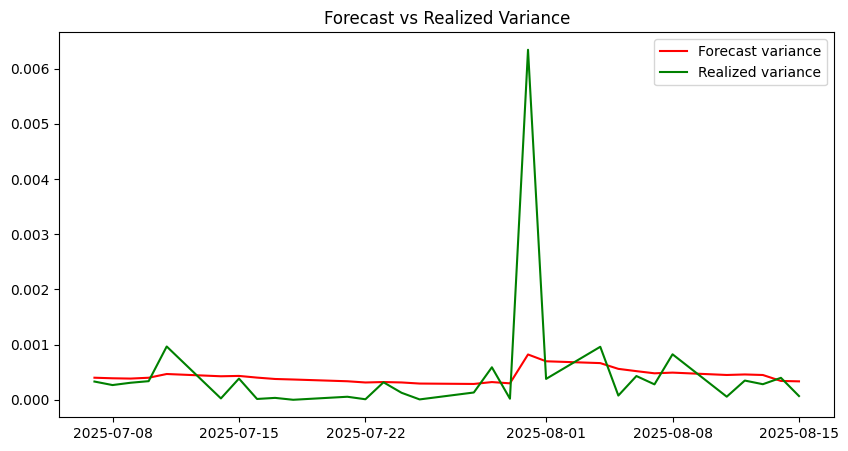

In [15]:
#
realized_var = returns**2

# Plot the forecast variance
plt.figure(figsize=(10,5))

plt.plot(forecast_var, label="Forecast variance", color="red")
plt.plot(realized_var['2025-07-07':'2025-08-15'], label="Realized variance", color="green")

plt.legend()
plt.title("Forecast vs Realized Variance")
plt.show()

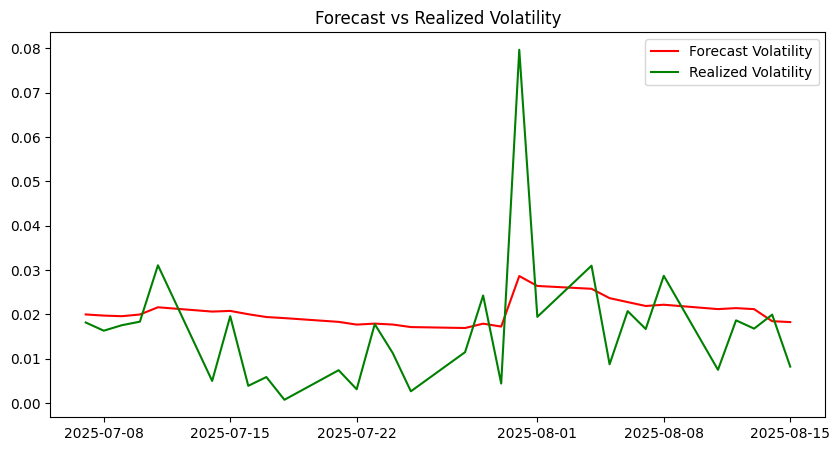

In [16]:
# Comparar volatility (std) en lugar de varianza. Ya que es más interpretable
import numpy as np

forecast_vol = np.sqrt(forecast_var)
realized_vol = np.sqrt(returns**2)

plt.figure(figsize=(10,5))

plt.plot(forecast_vol, label="Forecast Volatility", color="red")
plt.plot(realized_vol['2025-07-07':'2025-08-15'], label="Realized Volatility", color="green")

plt.legend()
plt.title("Forecast vs Realized Volatility")
plt.show()

## We saw predicted risk  vs  realized market movements
## What Are You Actually Plotting in This Rolling GARCH Forecast?

Your code performs a **rolling 1-step ahead volatility forecast** using a GARCH model.

The important idea is:

At each step you **re-estimate the model using a moving window of past data**, then **predict the variance for the next day**.

---

### Step 1 — Define the estimation window

You chose:

start_loc = 1800  
end_loc   = 1920

This means the model is first estimated using observations:

1800 → 1920

This is your **initial training window**.

Window size:

window_size = end_loc − start_loc

Example:

1920 − 1800 = 120 observations.

---

### Step 2 — What Happens Inside the Loop

For each iteration:

iteration 0

train model on:

1800 → 1920

forecast volatility for:

1921

---

iteration 1

train model on:

1801 → 1921

forecast volatility for:

1922

---

iteration 2

train model on:

1802 → 1922

forecast volatility for:

1923

---

This continues for:

30 iterations.

So you generate **30 one-step-ahead volatility forecasts**.

---

### Step 3 — What `forecast_var` Contains

After the loop you obtain a DataFrame like:

date        forecast variance
t1          σ²(t1+1)
t2          σ²(t2+1)
t3          σ²(t3+1)
...
t30         σ²(t30+1)

So you have **30 predicted volatilities**.

Important:

These are **out-of-sample predictions**.

They simulate what the model would have predicted **in real time**.

---

### Step 4 — What the Plot Shows

Your plot contains two series:

RED LINE

forecast_var

These are the **GARCH predicted variances** for each step.

They represent the model's estimate of:

future market volatility.

---

GREEN LINE

returns['2019-4-1':'2025-5-10']

These are the **actual realized returns**.

They represent the **true market movements**.

---

### Step 5 — What You Are Comparing

You are visually comparing:

predicted volatility  
vs  
realized returns

Interpretation:

large predicted variance → model expected large market moves  
small predicted variance → model expected calm market

So if volatility forecasts spike before large returns,
the model is capturing **volatility clustering** correctly.

---

### Step 6 — Why This Is Useful

This procedure is used for:

volatility forecasting  
risk management  
Value-at-Risk models  
portfolio risk estimation  
backtesting volatility models

In quantitative finance this is called:

**rolling out-of-sample volatility forecasting**.

---

### Step 7 — Time Range of the Forecasts

Your forecasts start roughly around the observation:

end_loc + 1

and continue for:

30 periods.

So the forecast period is approximately:

[end_loc + 1 , end_loc + 30]

depending on the dates corresponding to those indices.

---

## Key Intuition

The model is doing the following:

Use past data → estimate volatility model  
Predict tomorrow's volatility  
Move forward one day  
Repeat

This simulates **how the model would behave in real trading conditions**.

#  Significance testing of model parameters - Notes

GARCH models can have a lot of parameters, such as...
* omega
* alpha
* beta 
for difference lag periods
* lambda for GJR-GARCH, EGARCH and so on.

A valid question is: **do I need this parameter?**
Is it relevant and help to construct a better model? Or is it so close to zero that can we leave it out?

## Hypothesis test - Defining them
In our case, *the null hypothesis is: a parameter value is 0*. 
If H0 cannot be rejected, we should leave the parameter out of the GARCH model. **But this is dangerous; we could lose valuable information if we make a type 2 error.**

## Statistical significance - 0.05 chance of observing the result -TEST
(This is NOT DIRECTLY the p value, it is related with)
As a general rule, the significance level is commonly set to 0.05, **meaning that the probability of observing the results in our data by chance is just 5%**.

If we do not reject the null hypothesis i.e. it is true... we lead to the following concept:

## P value - Measure from the statistical significance test
**From a statistical significance test, we can obtain the p-value**
As we said, the statistical significance is not the p-value concept directly, the statistical significance TEST is used to compare with the predefined significance level to decide whether to reject or accept the null hypothesis.

### Definition of P-value - It is a probability
P-value is the probability value of obtaining the observed results of a test **assuming that the null hypothesis is true**

We can give it another sense...
**The lower the p-value**, the more surprising the evidence is, **the more ridiculous our null hypothesis looks**. 

## CONCEPTS RELATION:
**In other words, reject the null hypothesis if the p-value is smaller than the specified significance level, such as 5%.**

## In python...
GARCH model p-values can be reviewed in the model summary. We can also get them directly using "pvalues" (over the outcomes of the model, the results are the model fitted)


In [17]:
print(gm_result.pvalues)

mu          3.325055e-293
omega        0.000000e+00
alpha[1]     9.975912e-01
beta[1]      2.006158e-73
Name: pvalues, dtype: float64


## Interpretation
si p-value < 0.05  → rechazamos H0 → el parámetro es significativo
si p-value ≥ 0.05  → no rechazamos H0 → el parámetro podría ser 0

### No hay evidencia de efecto ARCH

## T-statistic - Another measure from the statistical significance test
**Key idea: Variable standarized...**
It is calculated as the estimated parameter value subtracted by its expected mean value, and then divided by its standard error...
ESTIMATED Param - E(mean) / std error

Since our null hypothesis assumes the parameter mean value is zero, it is simply the estimated parameter divided by the standard error.

THE OUTCOME... WHAT TELL US? *The absolute value of the t-statistic (the outcome of the previous calculation) is a distance measure*, that **tells us how many standard errors the estimated parameter is away from 0**. 
### Rule:
**The larger the distance, the more likely the parameter is not zero.**

### CONCEPTS RELATION
As a rule of thumb, if the t-statistic is larger than 2, we can reject the null hypothesis... i.e. the estimation of the parameter is valuable for the model.


In [18]:
print(gm_result.tvalues)

mu             36.595887
omega       35475.585027
alpha[1]        0.003019
beta[1]        18.125472
Name: tvalues, dtype: float64


# Workflow...
1. We define our hypothesis, commonly, the null hypothesis is that our ESTIMATED PARAMETERS are 0... notice that we may compare between many hypothesis at the same time.

2. We define our statistical significance... TESTING

**Making a  statistical signifcance test...**

If we DO NOT reject the hypothesis i.e. the parameter estimated gets the value of 0...

3. We COMPARE, we try to exaplin it with the P-value - a measure of the statistical signifcance test, the lower the p value, the more security we can reject the null hypotehsis... **so if it is greather than 0.05 we do not reject the null hypotehsis.**

4. There exists another measure of the statistical significance test, the t-statistics... ESTIMATED Param - E(mean) / std error
The larger the distance, the more likely the parameter is not zero.
In other words but with the same idea... if the t-statistic is larger than 2, we can reject the null hypothesis... i.e. the estimation of the parameter is valuable for the model.

### KEY
Our parameters... alpha, beta, lambda, etc, are estimations... by methods that we saw in inference statistics... like b_0 and b_1 in regression models.

In [19]:
# Get parameter stats from model summary
para_summary = pd.DataFrame({'parameter':gm_result.params,
                             'std-err': gm_result.std_err, 
                             't-value': gm_result.tvalues})

# Verify t-statistic by manual calculation
calculated_t = para_summary['parameter']/para_summary['std-err']

# Print calculated t-value
print(calculated_t)

# Print parameter stats
print(para_summary)

mu             36.595887
omega       35475.585027
alpha[1]        0.003019
beta[1]        18.125472
dtype: float64
          parameter       std-err       t-value
mu         0.002946  8.049103e-05     36.595887
omega      0.000008  2.115422e-10  35475.585027
alpha[1]   0.000180  5.950656e-02      0.003019
beta[1]    0.975938  5.384346e-02     18.125472


# Validation of GARCH model assumptions - standardized residuals epsilons
GARCH models make strict assumptions about the distribution characteristics of their standardized residuals... 
Remember that these are obatined by:
residuals = model_result.resid
cond_vol = model_result.conditional_volatility

**standardized_residuals = residuals / cond_vol**

If the model is doing a good job of explaining the data, the **standardized residuals should resemble a white noise process, which does not exhibit data clustering or autocorrelation.**

In a regressional model... the assuptiosn for the error - epsilons are an expected value of 0, consant variance (homo) and covariance between these independent varialbles (epsilons) equals to 0, (independence).

## Let's learn how to verify this.
### 1. Visual check
For starters, we can do a visual check by plotting the standardized residuals. As seen in the charts, the raw return data must exhibits clear signs of clustering. After fitting the GARCH models, the standardized residuals must not show much clustering and are close to a random white noise movement.

### 2. Autocorrelation
We can also use autocorrelation to **detect non-randomness (i.e not independency)** in the standardized residuals.
Autocorrelation describes the correlation of a variable with itself given a time lag.

*When exists autocorrelation?*
When there is a pattern such that values in the time series can be predicted based on preceding values in the series, the data exhibits autocorrelation.

*Interpretation*
And of course, **existence of autocorrelation in the standardized residuals indicates the model may not be sound**. 

### We can use ACF plots or statistical tests such as Ljung-Box to detect autocorrelations in the data.

### 3. ACF plot
**The coefficient of correlation** between two values in a time series is called the autocorrelation function or ACF.

*KEY idea to undestand how works*
For example, **a lag 1** autocorrelation is the correlation between values that are one period apart. 
More generally, **a lag k** autocorrelation is the correlation between values that are k-period apart. 

An ACF plot is a visual representation of correlations between different lags... 0, 1, 2, 3, k, etc.

*Special case, at lag 0*
At lag 0 the correlation is 1 as the data is perfectly correlated with itself.

**In lags other than 0... the important thing for the model is to find a low correlation!**

### CONFIDENCE LEVEL
For the other cases, lags other than 0... We can also specify a confidence level using alpha. For example, an alpha of point-05 means there is 5% chance the correlation will fall outside the band even the true correlation is zero.

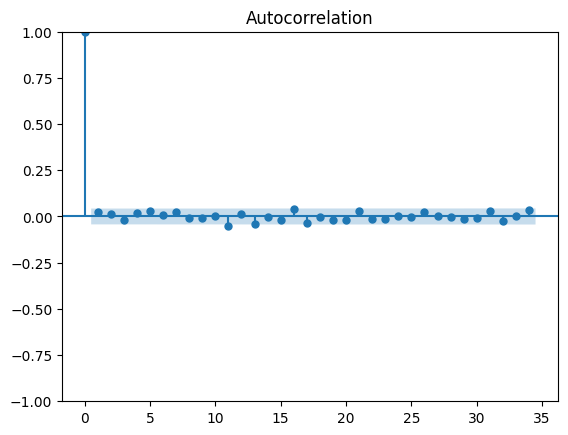

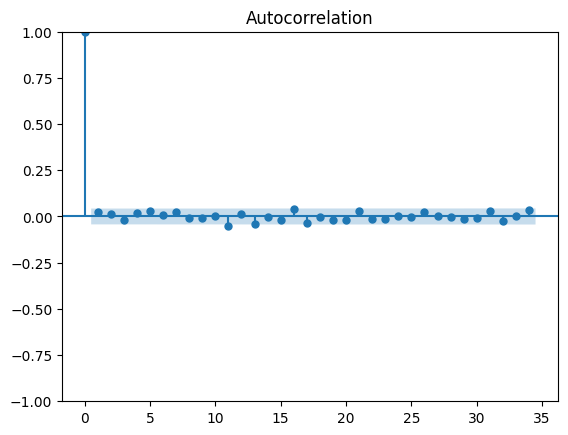

In [20]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(gm_std_resid, alpha =0.05) 
# Alpha is the confidence interval
# We plot the standarized residuals from the model... residuals/conditional_vol

# Ljung-Box test for autocorrelation - statistical test
Is a statistical test of whether any of a group of autocorrelations of a time series are different from zero. 
*Difference with the ACF plot*
Instead of testing randomness at each distinct lag, it tests the "overall" randomness based on a number of lags.

**The null hypothesis of Ljung-Box test is: the data is independently distributed.**

We still have the same ideas... **Recall we reject the null hypothesis if the p-value is smaller than the specified significance level, such as 5%**. 

### Reject H0 if the p-value is smaller that the specified significance
### Do not reject the H0 i.e the estimation is not valuable or is independent in this case IF the p-value is greater than the specified significance level.

In this case... the p-value less than 5% indicates that the residuals are not independently distributed, hence the model is not adequate.

ho - independence
We want in this case do not reject the H0 hypothesis...

In [21]:
from statsmodels.stats.diagnostic import acorr_ljungbox
#  Use "lags" to set the maximum number of time lags up to which the test will be performed
# Remember that we already defined the standard residuals... rediuals / coniditional_variability obtained from the model fitted
lb_test = acorr_ljungbox(gm_std_resid, lags = 10)

# From the test results, the p-values can be viewed from the second row of the results.
print('P-values are\n ', lb_test.iloc[:,1])


P-values are
  1     0.247582
2     0.415532
3     0.496061
4     0.553890
5     0.407341
6     0.524302
7     0.473741
8     0.572081
9     0.662187
10    0.747976
Name: lb_pvalue, dtype: float64


Since the p values are greater than 0.05... we DO NOT REJECT H0 i.e. THERE IS NOT EVIDENCE OF AUTOCORRELATION IN THE RESIDUALS.
The model GARCH... capturó correctamente la dependencia temporal de la serie los residuos estandarizados se comportan como ruido blanco. Eso es exactamente lo que queremos después de ajustar el modelo.

# Goofness of fit measures - Medida de bondad de ajuste - Which model is better? Likelihood and AIC/BIC measures

Measures of goodness of fit typically summarize the discrepancies between observed values and the values estimated by the model.
|y_i - y_1^(estimated)|

## Maximum likelihood
GARCH models use the "maximum likelihood method" to estimate parameters.

GARCH model log-likelihood values can be reviewed in the model summary. We can also get the value directly using "loglikelihood".

### INTERPREATION
**The bigger the likelihood, the better the model.**
For example..
Covariance estimator: robust
    Log-likelihood of normal GARCH : -2771.963828246164
    Log-likelihood of skewt GARCH : -2689.9795443769394
 The GARCH model with skewed Student's t-distribution assumption has a higher log-likelihood, hence is relatively better.

 *WE WILL GET A DIFFERNT INTERPREATION WITH AIC AND BIC MEASURES*

In [22]:
print(gm_result.loglikelihood)

292.70007985535335


## Overfiting
When noise or random fluctuations in the in-sample data is picked up and **learned as patterns by the model**, which does not apply to new information. 

The main idea using both concepts is the following:
**When fitting models, it is possible to increase the likelihood by adding parameters, but doing so may result in overfitting.**

Information criteria consider the model likelihood, but also add penalties for model complexity.

*A model with more parameters will have higher information criteria score given the same likelihood values.*

With this, comes the following concepts... 

## AIC and BIC
Remember that these are measures... like R^2, but r^2 is useful for one parameter, in this case we have at least 3... beta, gamma and alpha into the model...
y_i = beta + gamma + alpha + error

So... AIC and BIC penalizes the parameters to get a good measure of comparation between models.

*They are both used under the context of model selection, and the models with relatively lower AIC or BIC scores are preferred.*

Remember that theres is not a criteria to choose one over the other.
BIC makes a penalization harder than AIC...

*The main difference between AIC and BIC is the size of the penalty for model complexity. BIC imposes bigger penalties on models with more parameters, and leads to choosing more parsimonious models than does AIC.*

For example...
    AIC of GJR-GARCH model : 5294.232558095527
    AIC of EGARCH model : 5268.7919908309295
    BIC of GJR-GARCH model : 5328.769730159215
    BIC of EGARCH model : 5303.329162894618
**Both AIC and BIC of the EGARCH model are lower, hence EGARCH is relatively better.**

In [23]:
# The model already performeed both measures
print(gm_result.aic)
print(gm_result.bic)

-577.4001597107067
-566.2501927395786


# So far, my idea is fit different models for the asset volatility... and get its measures, make inference over its estimations, compare them... and then ¿?

# GARCH model backtesting

We will see how we can use backtesting as a handy tool to assess model performance, and how to quantify and compare backtesting results.

## Backtesting
Method to assess the quality of a model forecast.
**KEY: We compare the model predicted results with the actual historical data to see how close they are.** 
A satisfactory backtesting result will give us more confidence in the reliability of model predictions.

This part reseambles to the split data concept in ML... train and test sets.

Typically we can separate all the historical data we have at hand into two parts. The so-called “in-sample” data is used for modeling fitting, and the “out-of-sample” data is reserved for backtesting to evaluate model performance.

|---------------------|-------------|
      train (fit)          test
      in-sample         out-of-sample

I get the backtesting results... and then?

## MAE
We can use MAE to measure backtesting results.

*MAE = 1/N * SUM_{i=1}^{N} |y_i - y_i^(estimation)|*

Relatively, the smaller the MAE, the better the model performance.

## MSE - From ML
*Respecto a si es una loss function (función de pérdida) o una medida (métrica), el MSE puede actuar como ambas, dependiendo de la etapa del entrenamiento.*

*MSE = 1/N * SUM_{i=1}^{N} (y_i - y_i^)^2*

So similar to the MAE, the smaller the MSE, the better the model performance.

### KEY OBSERVATION, be carefull with the workflow and the units (specially when we fit the model, this will make more sense when we plot the information)


In [24]:
# WORKFLOW 
split_date = "2021-04-01"

from arch import arch_model

model = arch_model(returns*100, vol="Garch", p=1, q=1)

gm_result = model.fit(last_obs=split_date, disp="off")

# NOW, 2018 -------- 2021 -------- 2026 the model knows the entire temporal index.

# Now, we can do the forecast for the test

forecast = gm_result.forecast(start=split_date, horizon=1)

forecast_var = forecast.variance["h.1"]

# And we need the actual variance 
# PERO RECUERDA QUE el modelo predice varianza, entonces debemos comparar con varianza observada.
actual_var = actual_var = (returns[split_date:]*100)**2 # Ya que Var(r_t) ≈ r_t²
# !!!! If we do not multiply by 100... the comparision is:
# Forecast variance   → var(returns * 100)
# Observed variance   → var(returns)
# Since the fitting of the model, the model was learning... r_t (%)  and therefore the forecast is Var(r_t %) in other words (returns * 100)^2
common_index = forecast_var.index.intersection(actual_var.index)

forecast = forecast_var.loc[common_index]
observation = actual_var.loc[common_index]

print(forecast)
print(observation)


date
2021-04-01    5.976905
2021-04-06    5.737807
2021-04-07    5.153147
2021-04-08    4.655874
2021-04-09    4.784412
                ...   
2026-02-27    4.069555
2026-03-02    5.281644
2026-03-03    7.267324
2026-03-04    8.488225
2026-03-05    7.823287
Name: h.1, Length: 1261, dtype: float64
               return
date                 
2021-04-01   0.184283
2021-04-06   3.403174
2021-04-07   0.039524
2021-04-08   0.195960
2021-04-09   5.559536
...               ...
2026-02-27   3.032103
2026-03-02  15.003365
2026-03-03  23.483047
2026-03-04  18.167933
2026-03-05   2.289594

[1261 rows x 1 columns]


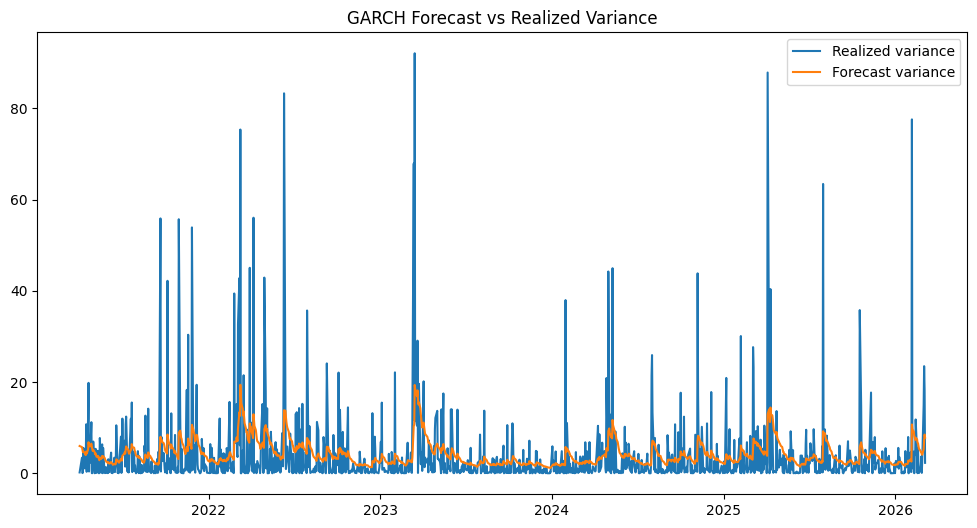

In [25]:
plt.figure(figsize=(12,6))

plt.plot(observation, label="Realized variance")
plt.plot(forecast, label="Forecast variance")

plt.legend()
plt.title("GARCH Forecast vs Realized Variance")
plt.show()

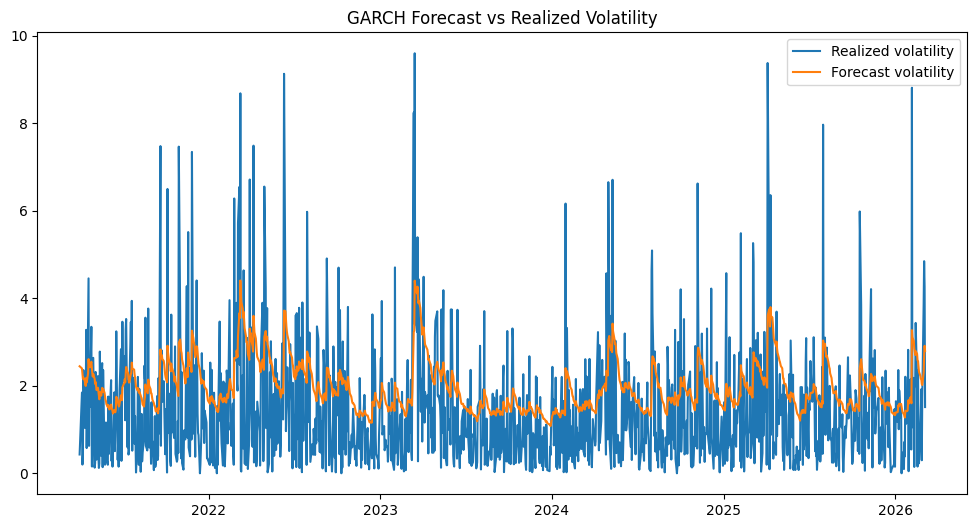

In [26]:
# Muchos papers prefieren comparar volatility (σ) en lugar de varianza. 
forecast_vol = np.sqrt(forecast)
realized_vol = np.sqrt(observation)

plt.figure(figsize=(12,6))

plt.plot(realized_vol, label="Realized volatility")
plt.plot(forecast_vol, label="Forecast volatility")

plt.legend()
plt.title("GARCH Forecast vs Realized Volatility")
plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Call function to calculate MAE
mae = mean_absolute_error(observation, forecast)
mse = mean_squared_error(observation, forecast)
print(mae)
print(mse)

3.9529533735699385
58.37345169270708


# VaR in financial risk management
We will discuss some practical applications of GARCH models in the financial world. Let's start with VaR in risk management.


VaR stands for "Value at Risk". It is an important concept in risk management **to quantify the potential losses**.

VaR is always discussed with three ingredients: 
* A portfolio
* A time horizon 
* A probability

VaR value indicates given a time horizon, the portfolio is likely to lose at least this much money given a specified probability.

For example:
* A 1-day 5% VaR of one million dollars means there is a 5% probability the portfolio will fall in value by 1 million dollars or more over a 1-day period.
* Likewise, a 10-day 1% VaR of $9 million means there is a 1% probability the portfolio will fall in value by 9 million dollars or more over a 10-day period.

*Hay una probabilidad del 1% de que el valor de la cartera caiga en 9 millones de dólares O MÁS durante un período de 10 días.*

* This can also be phrased as over the 10-day period, there is a 99% probability the portfolio will lose less than 9 million dollars.
*Durante el período de 10 días, existe una probabilidad del 99% de que la cartera pierda menos de 9 millones de dólares.*

**KEY, FINALLY UNDESTANDING THE Var CONCETP... For example... In our last investment we knew that the price of BBVA at the next day may be 172, the price at that moment was 185, so there was a high prorbability to loss at least $13... for me, in this sense... there was a probability of 80% that the value of the protfolio fall in value 13 or more over a period of 1 day... a 1-day 80% VaR of 13 pesos... in other words, over 1 day period, there is a 20% probability the portfolio will lose less than 13 pesos...**
In statistics we try to minimize by establishing the probability and maximum possible loss.

## VaR in risk management
As we said previusly... In financial risk management, **VaR is designed to gauge(indicar) potential portfolio losses and set risk limits**

When the portfolio loss exceeds the VaR, it is called a VaR exceedance.


**KEY: WE CAN PLOT THIS IDEA... Suppose a 5% daily VaR and 250 trading days in a year, a valid VaR model should have less than 13 VaR exceedances within a year, that is 5% times 250. If there are more exceedances, the model is underestimating the risk.**

##  Dynamic VaR with GARCH
GARCH models incorporate the time-varying characteristic of volatility
### Calculation of VaR - Key formula
*Portfolio expected mean return + a (quantile) * (the portfolio volatility)*

* Portfolio expected mean and volatility can be obtained from GARCH model forecast, so we do not need to obtain a portafolio separately.
* Note we get variance forecast directly from GARCH model, so we need to compute its square root before plugging in the VaR calculation.
* The quantile depends on a chosen confidence level, say 95% or 99%

### Now, calculation of Dynamic VaR
1.  first we fit a GARCH model and use it to make variance forecast (fit it and apply forecast with a start date, to make it dynamic we set it into a variable)

### Importance of start_date
Significa usar el modelo estimado
para generar pronósticos desde esa fecha
2018 ---------- 2025 ---------- futuro
     datos usados       VaR forecasts
     para estimar
Si cambias start_date, cambias desde cuándo empiezas a calcular VaR dinámico.
We can also define a last_date...

2. Obtain the mean and volatility of the forescast previsuly created since the date defined
3. Obtain the quantile according to a given confidence level...
**With GARCH, the quantile can be estimated parametrically with an assumed distribution, or empirically using historical data.**
3.1. Parametric VaR
    The parametric VaR with GARCH is estimated using quantiles from a parametric approach. That is, it is **based on GARCH assumed distribution** *of the standardized residuals*.
3.2  Empirical VaR
    The empirical VaR with GARCH is estimated with an empirical approach. That is, it is **based on the observed distribution** *of the GARCH standardized residuals.*


In [28]:
# 1
basic_gm = arch_model(returns, p = 1, q=1, mean = 'constant', vol = 'GARCH', dist = 't')

gm_result = basic_gm.fit()
start_date = '2025-03-04'
gm_forecast = gm_result.forecast(start = start_date)

# 2
mean_forecast = gm_forecast.mean[start_date : ]
variance_forecast = gm_forecast.variance[start_date :]

# 3
## 3.1
# Assume a Student´s t distribution
# ppf(): Percentt point function
nu = 3.01
q_parametric = basic_gm.distribution.ppf(0.05, nu)

## 3.2
q_empirical = gm_std_resid.quantile(0.05)

print(q_parametric)
print(q_empirical)

Iteration:      1,   Func. Count:      7,   Neg. LLF: 57798.24392355832
Iteration:      2,   Func. Count:     23,   Neg. LLF: 494883.1883083345
Iteration:      3,   Func. Count:     39,   Neg. LLF: 1347.8674988345874
Iteration:      4,   Func. Count:     45,   Neg. LLF: 1929210.2223679177
Iteration:      5,   Func. Count:     61,   Neg. LLF: 10558.790660150322
Iteration:      6,   Func. Count:     69,   Neg. LLF: 2456110.3944890373
Iteration:      7,   Func. Count:     85,   Neg. LLF: 62786.648579212655
Iteration:      8,   Func. Count:     92,   Neg. LLF: -2971.965279963446
Inequality constraints incompatible    (Exit mode 4)
            Current function value: -2971.965280021299
            Iterations: 12
            Function evaluations: 92
            Gradient evaluations: 8
-1.361377156988008
-1.7165731396143626


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004715. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/var/folders/kz/rybrs64563zc2gl94rf00qbw0000gn/T/ipykernel_52689/1561554729.py:4: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  gm_result = basic_gm.fit()


empirical < parametric
Esto significa que las colas empíricas son más pesadas que la distribución asumida.
En otras palabras... tu modelo paramétrico subestima pérdidas extremas

In [29]:
VaR_emp = mean_forecast.values + np.sqrt(variance_forecast).values * q_empirical
VaR_param = mean_forecast.values + np.sqrt(variance_forecast).values * q_parametric
print(VaR_emp)
print(VaR_param)

[[-0.07547962]
 [-0.12366709]
 [-0.09224174]
 [-0.05928132]
 [-0.04336948]
 [-0.02710058]
 [-0.08807301]
 [-0.04758661]
 [-0.09670937]
 [-0.06637779]
 [-0.08454561]
 [-0.04488251]
 [-0.03603598]
 [-0.04516557]
 [-0.05369597]
 [-0.08319978]
 [-0.04568126]
 [-0.02987766]
 [-0.04160689]
 [-0.0277438 ]
 [-0.07161722]
 [-0.04912125]
 [-0.02966692]
 [-0.13883302]
 [-0.08450622]
 [-0.0557426 ]
 [-0.03481249]
 [-0.14603061]
 [-0.06743181]
 [-0.09986754]
 [-0.08689603]
 [-0.05929148]
 [-0.03993667]
 [-0.05260472]
 [-0.10456481]
 [-0.05290616]
 [-0.07308569]
 [-0.06731347]
 [-0.03662444]
 [-0.02850122]
 [-0.06613819]
 [-0.0763876 ]
 [-0.06055118]
 [-0.05318595]
 [-0.07865381]
 [-0.0541634 ]
 [-0.07507   ]
 [-0.07188517]
 [-0.07002232]
 [-0.04574412]
 [-0.05304892]
 [-0.0550393 ]
 [-0.0824227 ]
 [-0.04818103]
 [-0.04560649]
 [-0.04055366]
 [-0.06602497]
 [-0.06180207]
 [-0.03592113]
 [-0.04690831]
 [-0.04263505]
 [-0.04760227]
 [-0.04114048]
 [-0.04117627]
 [-0.05562261]
 [-0.05272966]
 [-0.04898

If VaR_t = -0.05048 the interpreation is the follwing: 
Con 95% de confianza, la pérdida mañana NO superará 5.05%.
Hay 5% de probabilidad de perder MÁS de 5.05%.
| Día | VaR   | Interpretación                        |
| --- | ----- | ------------------------------------- |
| t   | -5.0% | 5% probabilidad de perder más de 5%   |
| t+1 | -7.4% | 5% probabilidad de perder más de 7.4% |
| t+2 | -5.8% | 5% probabilidad de perder más de 5.8% |

Cuando el mercado está más volátil, el VaR se hace mas negativo...
VaR = -0.1145
5% probabilidad de perder más de 11.45%


5% parametric quantile:  -1.361377156988008


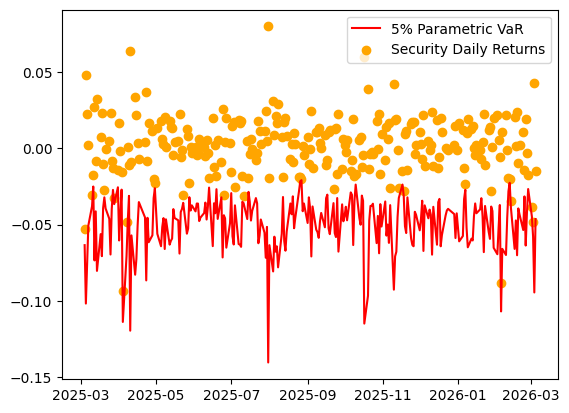

In [30]:
# Obtain the parametric quantile
q_parametric = basic_gm.distribution.ppf(0.05, nu)
print('5% parametric quantile: ', q_parametric)
    
# Calculate the VaR
VaR_parametric = mean_forecast.values + np.sqrt(variance_forecast).values * q_parametric
# Save VaR in a DataFrame
VaR_parametric = pd.DataFrame(VaR_parametric, columns = ['5%'], index = variance_forecast.index)

# Plot the VaR
plt.plot(VaR_parametric, color = 'red', label = '5% Parametric VaR')
plt.scatter(variance_forecast[start_date:].index, returns[start_date:], color = 'orange', label = 'Security Daily Returns' )
plt.legend(loc = 'upper right')
plt.show()

 In the plot, the returns plotted by orange dots down of the red line are examples of VaR exceedance, since they have fallen below the VaR threshold line in red. 
 Suppose a 5% daily VaR and 250 trading days in a year, a valid VaR model should have less than 13 VaR exceedances within a year, that is 5% times 250. If there are more exceedances, the model is underestimating the risk.


With this, we simply assess the model, is a kind of backtesting... we are not making future predictions, since we define a start date we are watching how the model performance... 

Then of this we can make predictions (get h1)

And apply to the following cases:
### Gestión de portafolios

Un gestor puede establecer límites de riesgo basados en Value at Risk (VaR).

Ejemplo:

```
Regla del portafolio:
No quiero más de 3% de VaR diario.
```

Si el modelo estima:

```
VaR(95%) = -7%
```

Interpretación:

```
Existe un 5% de probabilidad de perder más de 7% del portafolio en un día.
```

Decisión del gestor:

```
El riesgo estimado excede el límite permitido.
→ Reducir posiciones en el portafolio.
→ Disminuir exposición al mercado.
```

---

### Control de riesgo en trading

Muchos hedge funds utilizan reglas automáticas basadas en VaR.

Ejemplo:

```
Regla de trading:
Si VaR > 8%
↓
cerrar posiciones
```

Interpretación:

```
El modelo indica que el riesgo del mercado es demasiado alto.
El sistema reduce o liquida posiciones para evitar pérdidas extremas.
```

Este tipo de reglas se usan para:

* proteger capital
* limitar drawdowns
* controlar exposición en momentos de alta volatilidad

---

### Ejemplo práctico

Supón que gestionas un fondo con un valor de:

```
$1,000,000
```

Tu modelo de riesgo estima:

```
VaR(95%) = -5%
```

Interpretación:

```
Existe un 5% de probabilidad de perder más de 5% del portafolio en un día.
```

Pérdida potencial:

```
5% de $1,000,000 = $50,000
```

Entonces el VaR indica:

```
Hay un 5% de probabilidad de perder más de $50,000 mañana.
```

Este valor permite al gestor:

* evaluar el riesgo del portafolio
* ajustar posiciones
* decidir si necesita cobertura (hedging)
* cumplir con límites regulatorios de riesgo


#  Dynamic covariance in portfolio optimization
Correlations is not the same with Covariance.

GARCH model takes the time-varying characteristic of volatility into consideration. Dynamic covariance can be computed by multiplying correlation *coefficient between asset returns* by their volatility from GARCH models.
If two asset returns hace correlation pa dn time-varying volatility of sigma_1 and sigma_2

*Covariance = p * sigma_2, sigma_2 = correlation * garch_vol1 * garch_vol2*

### In python..
1. Fit GARCH models for each return series and obtain their volatility estimations...

Suppose we have two foreign currency asset Euro and Canadian dollars, and their return time series data has been fitted by two GARCH models: gm_eur and gm_cad. 

2. We can directly obtain the volatility from the GARCH models. 

3. Compute the standardized residuals from the fitted GARCH models...
*standarized_residuals = residuals - 0 /conditional_volatility*

4. Then we need to compute the correlation coefficient as the simple correlation between standardized residuals (resid_eur, resid_cad). This can be done using "corrcoef()" method from the "numpy" package.

Remember that this functions return us a matrix... so we need to use indexation to take its corr value.
*corr = np.corrcoef(resid_eur, resid_cad)[0,1]*

4. Compute GARCH covariance by multiplying the correlation and volatility

5. We can even plot the covariance...

Optimization terminated successfully    (Exit mode 0)
            Current function value: -5259.867930881595
            Iterations: 2
            Function evaluations: 27
            Gradient evaluations: 2
Optimization terminated successfully    (Exit mode 0)
            Current function value: -6604.557658445248
            Iterations: 6
            Function evaluations: 18
            Gradient evaluations: 2
Correlation:  0.38203405813245017


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0004715. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001504. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._

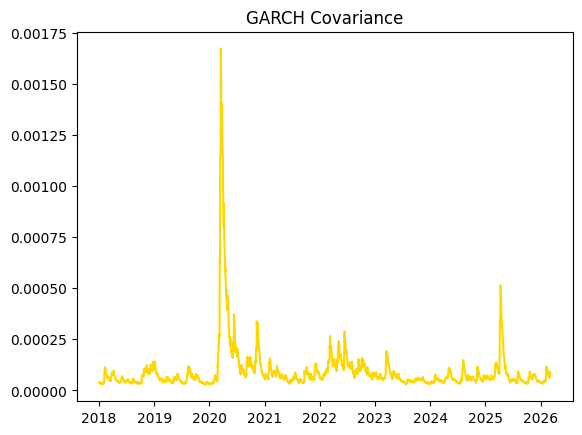

In [55]:
# Asset to analyze
ric1 = "BBVA"
ric2 = 'SPX'

# Create analysis object
asset1 = market_data.distribution_manager(ric1)
asset2 = market_data.distribution_manager(ric2)

# Load time series and compute returns
asset1.load_timeseries() # from_date='2025-12-02'
asset2.load_timeseries()

# Convert date column to datetime
asset1.timeseries['date'] = pd.to_datetime(asset1.timeseries['date'])
asset2.timeseries['date'] = pd.to_datetime(asset2.timeseries['date'])

# Set date as index
asset1.timeseries= asset1.timeseries.set_index('date')
asset2.timeseries= asset2.timeseries.set_index('date')

# Keep only returns
returns1 = asset1.timeseries[['return']] # We keep the dates data since we did it the indexation
returns2 = asset2.timeseries[['return']]

# Dates interesction to avoid future troubles of indexation
common_dates = returns1.index.intersection(returns2.index)

# We need to fit a model for both assets
# GARCH model with constant mean
mod1 = arch_model(returns1, p = 1, q = 1, mean = 'constant', vol = 'GARCH', dist = 'normal')
mod1_result = mod1.fit(update_freq = 4)

# GARCH model with constant or AR mean
mod2 = arch_model(returns2, p = 1, q = 1, mean = 'constant', vol = 'GARCH', dist = 'normal')
mod2_result = mod2.fit(update_freq = 4)

# Plot model volatility
vol1 = mod1_result.conditional_volatility.loc[common_dates]
vol2 = mod2_result.conditional_volatility.loc[common_dates]

# Take the residuals
resid1 = mod1_result.resid.loc[common_dates]
resid2 = mod2_result.resid.loc[common_dates]

# Calculate correlation
corr = np.corrcoef(resid1, resid2)[0,1]
print('Correlation: ', corr)

# Calculate GARCH covariance
covariance =  corr * vol1 * vol2

# Plot the data
plt.plot(covariance, color = 'gold')
plt.title('GARCH Covariance')
plt.show()

# MODERN PORTFOLIO THEORY
In a nutshell, MPT states that there is an optimal way to structure a portfolio with various assets to take advantage of the diversification effect.

The optimal portfolio can yield(producir) the maximum possible return with the minimum risk.
In other words...
* An investor can construct a portfolio of multiple assets that will **maximize returns for a given level of risk**. 
* Likewise, **given a desired level of expected return**, an investor can construct a portfolio **with the lowest possible risk.**

## Intuition
The portfolio variance can be computed by this formula with:
* asset weights (W_i)
* variances of individual asset returns
* their covariance

### KEY of diverisificaction:
Note when combining assets into a portfolio, MPT shows **including assets with a negative covariance can reduce the overall risk of the portfolio.**

In this sense, an individual asset's return is less important than how the asset behaves in relation to each other, or in the context of the entire portfolio. 

Incorporating GARCH models while computing the covariance, we can make more realistic estimations during the portfolio construction process.

*Var(1, 2) = W1^2 * Var1 + W2^2 * Var2 + 2 * W_1 * W_2 * COVARIANCE*




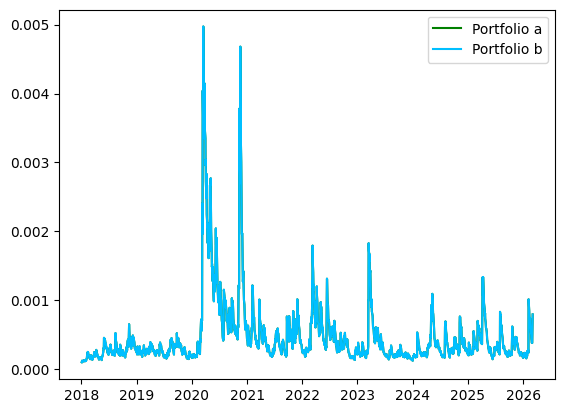

In [ ]:
# Define weights
Wa1 = 0.9
Wa2 = 1 - Wa1
Wb1 = 0.5
Wb2 = 1 - Wb1

# Calculate portfolio variance
# We will use the conditional variance... this is equals to conditional_volatility^2 = variance, we do not use the forecast!
portvar_a = Wa1**2 * vol1**2 + Wa2**2 * vol2**2 + 2*Wa1*Wa2 *covariance
portvar_b = Wb1**2 * vol1**2 + Wb2**2 * vol2**2 + 2*Wb1*Wb2*covariance

# Plot the data
plt.plot(portvar_a, color = 'green', label = 'Portfolio a')
plt.plot(portvar_b, color = 'deepskyblue', label = 'Portfolio b')
plt.legend(loc = 'upper right')
plt.show()

If portfolio b is below portfolio a, that could mean that portfolio b is much less volatile compared to portfolio a. Even just for a simple two-asset portfolio, **how you structure it can greatly alter the risk profile.**

# Dynamic Beta in portfolio management
Beta: Is the asset worth investing in? 
It help us to estimate the risk premium

In finance, stock Beta is a **risk measure for an individual stock in relation to the general market**. 

For US stocks, the S&P 500 index is commonly used as a proxy for the general market.

Beta is important because **it measures the risk of an investment that cannot be reduced by diversification.** 
In other words, it does not measure the risk of an investment asset held on a stand-alone basis (de forma independiente), but(sino) **the amount of risk the investment adds to the portfolio.**

## Interpretation
In portfolio management, Beta is a useful **gauge of investment risk of individual stocks in comparison with the general market**. 

**As the general market has a Beta of 1**, a stock with Beta greater than 1 indicates the stock is theoretically riskier. 

For example, a stock with a Beta of 1-point-2 implies the stock is about 20% more volatile than the general market. Likewise, a stock with Beta less than 1 implies it is less volatile.

## BETA in CAPM
**Stock Beta is needed to compute the risk premium** for an individual stock. *The higher the Beta, the riskier the stock, and hence* **the higher the required rate of return...**

The CAPM equation demonstrates **how to determine the required rate of return of an investment asset...**
We need:
* The risk free rate
* Market expected return 
* The stock Beta as input to the equation
Where
* Commonly risk free rate is the return of government treasury as a proxy
* Market expected return for stocks is S&P 500
* Beta is multiplied by the difference between market return and risk free rate, or market premium, to derive the expected extra return of a stock.

Estimar la risk premium (prima de riesgo) de una acción te sirve para determinar si la rentabilidad esperada justifica el riesgo de perder capital en comparación con una inversión segura. Ayuda a valorar si una acción está cara o barata, calcular el coste del capital y tomar decisiones de inversión fundamentadas.

## Compute the dynamic beta WITH GARCH
A stock Beta can be computed by multiplying *correlation between the stock returns* and market returns by the stock volatility, then divided by the market volatility. 

The correlation and volatility are estimated from the GARCH models, which take account the time-varying characteristic of risks.
*Beta = (p * sigma_stock)/sigma_market*

### In python
The sample code demonstrates how to calculate dynamic stock Beta in relation to the general market, which use the S&P 500 index as a proxy.

1. We can estimate the correlation from the GARCH standardized residuals. 

Recall the standardized residuals can be computed using the fitted GARCH model.

*standarized_res = model.resid / model.conditional_vol*

2. Then we compute the correlation with the Numpy corrcoef function

3. Then the stock Beta can be computed by multiplying the correlation and stock volatility, then divided by the market volatility.

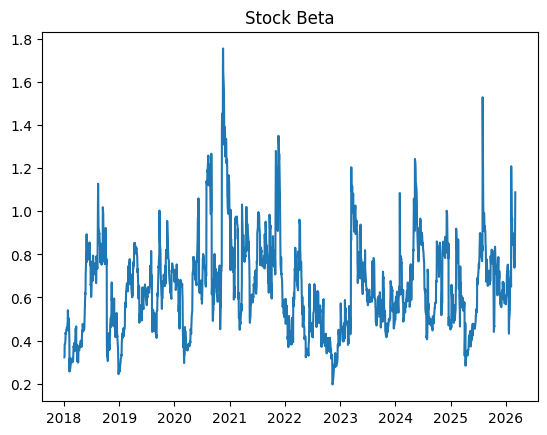

In [ ]:
# Compute correlation between SP500 and Tesla
correlation = np.corrcoef(resid1/vol1, resid2/vol2)[0, 1]

# Compute the Beta for Tesla
stock_beta = correlation * (vol1 / vol2) # vol2 must be the conditional volatility of the market used as a proxy.

# Plot the Beta
plt.title('Stock Beta')
plt.plot(stock_beta)
plt.show()